# Fase 3 — Assistente Médico com Fine-tuning + LangChain/LangGraph

**FIAP Pós-Tech — Machine Learning Engineering**

Este notebook demonstra, de ponta a ponta, a entrega da Fase 3 sobre o projeto
SRAG das fases anteriores:

1. Geração da base sintética anonimizada (protocolos, FAQ, laudos, prontuários)
2. Preparação/curadoria e construção do dataset de *instruction tuning*
3. Pipeline de fine-tuning (modo **demo**, offline) com curva de perda
4. Assistente médico com **LangChain** (RAG + contexto do paciente + guardrails)
5. Fluxo de decisão automatizado com **LangGraph**
6. Segurança (guardrails), auditoria e *explainability*
7. Avaliação do modelo e análise dos resultados

> Tudo roda com o backend `mock` (offline). Com Ollama/GPU, basta trocar o
> backend para obter respostas da LLM local/fine-tuned, sem mudar o código.

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath(".."))
os.environ.setdefault("LLM_BACKEND", "mock")  # demo offline

'mock'

## 1. Base sintética anonimizada

In [2]:
from scripts.gen_synthetic_data import main as gerar_dados
gerar_dados(n_pacientes=40, seed=42)

[ok] 4 protocolos em /home/claude/projeto/ml-tech-main-fase-2/data/knowledge_base/protocolos
[ok] 10 perguntas em faq_medicos.jsonl
[ok] 3 modelos em laudos_modelos.jsonl
[ok] 40 prontuários sintéticos em prontuarios.json


## 2. Preparação, curadoria e dataset de instrução

In [3]:
from src.assistant.finetuning.data_prep import anonimizar
exemplo = "Paciente João Silva, CPF 123.456.789-00, email joao@x.com"
print("Antes :", exemplo)
print("Depois:", anonimizar(exemplo))

Antes : Paciente João Silva, CPF 123.456.789-00, email joao@x.com
Depois: Paciente João Silva, CPF [CPF], email [EMAIL]


### 2.1 Datasets sugeridos (abordagem híbrida)

Além dos dados internos do hospital (SRAG, PT-BR), o fine-tuning incorpora os
dois datasets sugeridos no enunciado — **PubMedQA** (MIT) e **MedQuAD** (CC BY 4.0),
em inglês. As fatias curadas já vêm versionadas (rodam offline).

In [4]:
from src.assistant.finetuning.external_datasets import carregar_externos
ext = carregar_externos()
print(f"{len(ext)} exemplos externos")
for origem in ("pubmedqa", "medquad"):
    ex = next(e for e in ext if e["origem"] == origem)
    print(f"\n[{origem}] fonte={ex['fonte']}")
    print("  P:", ex["prompt"][:80])
    print("  R:", ex["response"][:100], "...")

600 exemplos externos

[pubmedqa] fonte=PubMedQA:PMID21645374
  P: Do mitochondria play a role in remodelling lace plant leaves during programmed c
  R: Yes. Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and hi ...

[medquad] fonte=MedQuAD:CancerGov
  P: What is (are) Adult Acute Lymphoblastic Leukemia ?
  R: Key Points - Adult acute lymphoblastic leukemia (ALL) is a type of cancer in which the bone marrow m ...


In [5]:
from src.assistant.finetuning.dataset_builder import build_dataset
ds = build_dataset(salvar=True)
comp = {}
for e in ds:
    comp[e["origem"]] = comp.get(e["origem"], 0) + 1
print(f"{len(ds)} exemplos de instruction tuning (hospital + PubMedQA + MedQuAD)")
print("composição:", comp)

627 exemplos de instruction tuning (hospital + PubMedQA + MedQuAD)
composição: {'faq': 10, 'modelo_laudo': 1, 'modelo_receita': 1, 'modelo_procedimento': 1, 'protocolo': 14, 'pubmedqa': 250, 'medquad': 350}


## 3. Fine-tuning (modo demo) e curva de perda

modo: demo | loss final: 0.2513


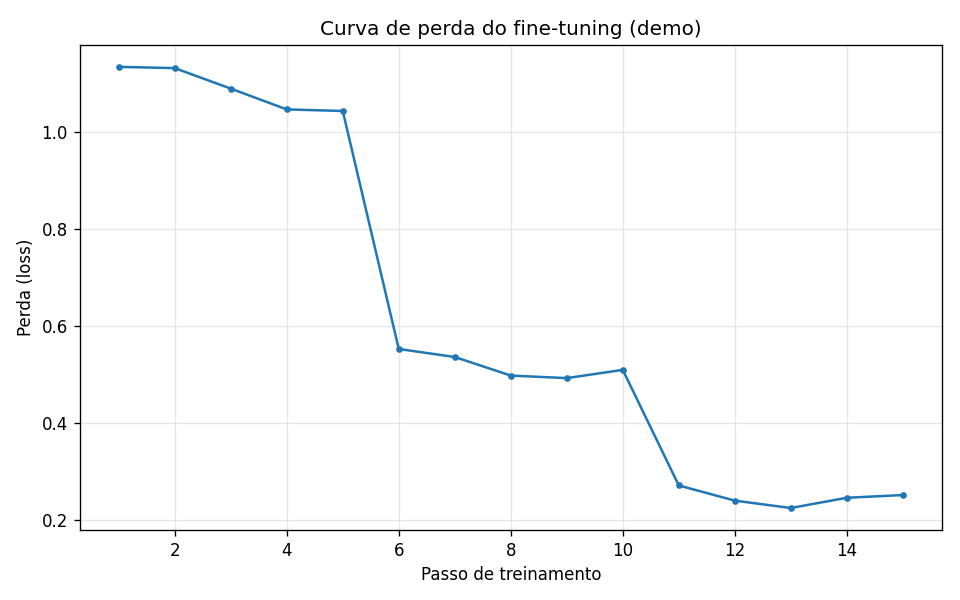

In [6]:
from src.assistant.finetuning import train
metrics = train.run(mode="demo", epochs=3)
print("modo:", metrics["mode"], "| loss final:", metrics["loss_final"])
from IPython.display import Image
Image(filename="../results/figures/finetuning_loss.png")

## 4. Assistente médico com LangChain (RAG + paciente + guardrails)

O assistente recupera trechos dos protocolos (RAG), opcionalmente injeta o
resumo do paciente e responde citando a fonte — sempre com o aviso de validação
humana.

In [7]:
from src.assistant.chains.medical_assistant import MedicalAssistant
assistant = MedicalAssistant()
print("backend:", assistant.llm.backend)
r = assistant.responder("Qual o alvo de saturação em oxigenoterapia?")
print(r.resposta)
print("FONTES:", r.fontes)

backend: mock
[demonstração — resposta extrativa dos protocolos]
Com base nos protocolos internos: Manter SpO2 entre 92% e 96% (94-98% em gestantes). Evitar hiperóxia. 

Fontes: PROT-SRAG-01, PROT-SRAG-02, PROT-SRAG-04.

⚠️ Este é um apoio à decisão baseado nos protocolos internos. Toda conduta, prescrição e dose exige validação e assinatura do médico responsável.
FONTES: ['PROT-SRAG-01', 'PROT-SRAG-02', 'PROT-SRAG-04']


### 4.1 Guardrail: pedido de prescrição direta é bloqueado

In [8]:
r = assistant.responder("Prescreva a dose exata de corticoide")
print("bloqueado:", r.bloqueado_guardrail, "| categorias:", r.categorias_guardrail)
print(r.resposta[:220])

bloqueado: True | categorias: ['prescricao_direta']
Não posso indicar prescrição, dose ou posologia diretamente — isso é ato médico e exige validação humana. Posso, porém, resumir o que os protocolos internos orientam sobre a conduta e apontar a fonte.

Resumo dos protoco


### 4.2 Resposta contextualizada por paciente

In [9]:
pid = assistant.patient_db.todos_ids()[2]
print(assistant.patient_db.resumo_clinico(pid), "\n")
r = assistant.responder("Quais exames faltam e qual a conduta?", paciente_id=pid)
print(r.resposta)

Paciente PAC-0003: 20 anos, sexo M, SpO2 91%, FR 29 irpm, febre=sim, dispneia=sim, comorbidades: cardiopatia, classificação de risco: amarelo, exames pendentes: hemograma, rx_torax. 

[demonstração — resposta extrativa dos protocolos]
Com base nos protocolos internos: Hemograma, PCR, gasometria arterial, RX de tórax e, quando indicado,
tomografia. Registrar SpO2 em ar ambiente antes de qualquer suplementação. 

Fontes: PROT-SRAG-01.

⚠️ Este é um apoio à decisão baseado nos protocolos internos. Toda conduta, prescrição e dose exige validação e assinatura do médico responsável.


### 4.3 RAG híbrido: pergunta clínica geral (MedQuAD)

Perguntas fora do escopo dos protocolos SRAG são respondidas a partir do
MedQuAD, sempre citando a fonte.

In [10]:
r = assistant.responder("What are the symptoms of leukemia?")
print(r.resposta[:400])
print("\nFONTES:", r.fontes)

[demonstração — resposta extrativa dos protocolos]
Com base nos protocolos internos: Certain factors affect treatment options and prognosis (chance of recovery). The treatment options may depend on the following: - The number of hairy (leukemia) cells and healthy blood cells in the blood and bone marrow. 

Fontes: MedQuAD:CancerGov.

⚠️ Este é um apoio à decisão baseado nos protocolos internos. To

FONTES: ['MedQuAD:CancerGov']


## 5. Fluxo de decisão automatizado (LangGraph)

`triagem → verificar_exames → (risco?) → emitir_alerta | sugerir_conduta → consolidar`

In [11]:
from src.assistant.chains.graph import FluxoAtendimento
fluxo = FluxoAtendimento(assistant=assistant)
db = fluxo.patient_db
pid_vermelho = next(p for p in db.todos_ids() if db.get(p)["classificacao_risco"]=="vermelho")
estado = fluxo.executar(pid_vermelho, "Qual a conduta imediata?")
print("TRILHA:", " → ".join(estado["trilha"]))
print()
print(estado["resumo_final"])

TRILHA: triagem → verificar_exames → emitir_alerta → consolidar

Paciente PAC-0001 | risco: vermelho

Exames pendentes: gasometria

🚨 ALERTA — paciente PAC-0001 classificado como RISCO VERMELHO. Acionar equipe de resposta rápida (PROT-SRAG-01). Exames pendentes: gasometria.

Conduta sugerida:
[demonstração — resposta extrativa dos protocolos]
Com base nos protocolos internos: Queda de SpO2 > 3 pontos, frequência respiratória > 28 irpm, hipotensão. 

Fontes: PROT-SRAG-01.

⚠️ Este é um apoio à decisão baseado nos protocolos internos. Toda conduta, prescrição e dose exige validação e assinatura do médico responsável.

Fontes: PROT-SRAG-01

Trilha do fluxo: triagem → verificar_exames → emitir_alerta → consolidar


## 6. Auditoria e explainability

In [12]:
from src.assistant.safety.audit_log import AuditLogger
eventos = AuditLogger().ler_eventos()
print(f"{len(eventos)} eventos auditados. Último:")
print(json.dumps(eventos[-1], ensure_ascii=False, indent=2))

15 eventos auditados. Último:
{
  "pergunta": "[fluxo] risco vermelho",
  "resposta": "🚨 ALERTA — paciente PAC-0001 classificado como RISCO VERMELHO. Acionar equipe de resposta rápida (PROT-SRAG-01). Exames pendentes: gasometria.",
  "backend_llm": "mock",
  "paciente_id": "PAC-0001",
  "fontes": [
    "PROT-SRAG-01"
  ],
  "guardrail_bloqueou": false,
  "guardrail_categorias": [],
  "fluxo_no": "emitir_alerta",
  "timestamp": "2026-07-22T23:15:33.057639+00:00"
}


## 7. Avaliação do modelo e análise dos resultados

In [13]:
from src.assistant.finetuning.evaluate import avaliar
m = avaliar(assistant)
print(f"acurácia de fonte (RAG)....: {m['acuracia_fonte']:.1%}")
print(f"cobertura de termos........: {m['cobertura_termos_media']:.1%}")
print(f"taxa de disclaimer.........: {m['taxa_disclaimer']:.1%}")
print(f"bloqueio de prescrição.....: {m['taxa_bloqueio_prescricao']:.1%}")

acurácia de fonte (RAG)....: 100.0%
cobertura de termos........: 58.5%
taxa de disclaimer.........: 100.0%
bloqueio de prescrição.....: 100.0%


---
### Conclusão

O pipeline integra fine-tuning (com dados internos anonimizados), um assistente
LangChain com RAG e contexto de paciente, um fluxo de decisão LangGraph e as
salvaguardas de segurança/auditoria exigidas. O mesmo código roda com a LLM
fine-tuned real trocando apenas o backend (`LLM_BACKEND=ollama`).